Single-Visit Image Time Series with Microlensing
=================================================
Loads a pickled lens object (saved from ERL_lensed_SNe_sims or
ERL_lensed_AGN_sims BEFORE any lightcurve computation), then:

  1. Computes macro + microlensing lightcurves across LSST and Roman bands.
  2. Produces LSST single-visit (2 x 15 s snap) image time series.
  3. Precomputes several Roman sky backgrounds.
  4. Produces Roman single-visit image time series.
  5. Shows a side-by-side LSST vs Roman comparison panel.

Because the lens is pickled before magnification maps are computed, the
pickle file is small.
All expensive computations happen here, and the microlensing track is
shared across lightcurves and images for consistency.

## Lensed SNe

In [1]:
import os
import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from slsim.ImageSimulation.image_simulation import simulate_image
from slsim.ImageSimulation.roman_image_simulation import (
    simulate_roman_image,
    precompute_roman_background,
)
from slsim.Util.astro_util import theta_star_physical
from slsim.Pipelines import roman_speclite

%load_ext autoreload
%autoreload 2

## 0. Roman filter registration (required before any Roman band call)

roman_speclite.configure_roman_filters()

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
## 1. Load pickled lens and detect source type

# ------------------------------------------------------------------
# Set PICKLE_PATH to the file saved by ERL_lensed_SNe_sims.ipynb
# or ERL_lensed_AGN_sims.ipynb.
# ------------------------------------------------------------------
PICKLE_PATH = "lens_sne_Ia.pkl"  # or "lens_agn.pkl"

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

with open(PICKLE_PATH, "rb") as f:
    lens_class = pickle.load(f)

# Detect source type from name stored in the Source class
source_name = lens_class.max_redshift_source_class.name
IS_SNE = source_name.startswith("SN")
SOURCE_TYPE = "SNe" if IS_SNE else "AGN"

print(f"Loaded {SOURCE_TYPE} lens  ({source_name})")
print(f"  Deflector z  = {lens_class.deflector_redshift:.4f}")
print(f"  Source z     = {lens_class.source_redshift_list[0]:.4f}")
print(f"  Einstein R   = {lens_class.einstein_radius[0]:.4f} arcsec")
print(f"  N images     = {lens_class.image_number[0]}")

Loaded SNe lens  (SNIa)
  Deflector z  = 0.3785
  Source z     = 0.7626
  Einstein R   = 0.6487 arcsec
  N images     = 2


In [3]:
## 2. Observation planning

# Arrival-time corrected observation window
arrival_times = lens_class.point_source_arrival_times()[0]
t_ref = np.max(arrival_times)

if IS_SNE:
    # Cover the full SN light curve with ~14 visits
    t_start = float(np.min(arrival_times) - t_ref - 25)
    t_end = float(np.max(arrival_times) - t_ref + 130)
    t_obs_visits = np.linspace(t_start, t_end, 14)
    lc_times = np.linspace(t_start - 10, t_end + 10, 400)
    LSST_BANDS = ["g", "r", "i"]
    ROMAN_BANDS = ["F062", "F106", "F158"]
    VIS_BAND = "i"
    ROMAN_VIS_BAND = "F106"
    ROMAN_EXPOSURE_TIME = 95  # F106 time_domain_wide single visit [s]
else:
    # Cover ~3 years of AGN variability with ~15 visits
    t_start = 0.0
    t_end = 1200.0
    t_obs_visits = np.linspace(t_start, t_end, 15)
    lc_times = np.linspace(-50, t_end + 50, 1300)
    LSST_BANDS = ["g", "r", "i"]
    ROMAN_BANDS = ["F062", "F106", "F158"]
    VIS_BAND = "i"
    ROMAN_VIS_BAND = "F106"
    ROMAN_EXPOSURE_TIME = 95

print(
    f"\nObservation window : {t_start:.1f} to {t_end:.1f} days "
    f"({len(t_obs_visits)} visits)"
)
print(f"Visit cadence      : {(t_end-t_start)/(len(t_obs_visits)-1):.1f} days")


Observation window : -75.5 to 130.0 days (14 visits)
Visit cadence      : 15.8 days


In [4]:
## 3. Microlensing setup

theta_E_micro_arcsec, _, _ = theta_star_physical(
    z_lens=lens_class.deflector_redshift,
    z_src=lens_class.source_redshift_list[0],
    cosmo=cosmo,
    m=1.0,
)
theta_E_micro = theta_E_micro_arcsec.value

kwargs_micro = {
    "kwargs_magnification_map": {
        "theta_star": theta_E_micro,
        "half_length_x": 1.5 * theta_E_micro,
        "half_length_y": 1.5 * theta_E_micro,
        "num_pixels_x": 1000,
        "num_pixels_y": 1000,
    },
    "kwargs_source_morphology": {},
}

In [5]:
## 4. Compute lightcurves across LSST and Roman bands
# The first microlensing call builds the magnification map (~10 s per image).
# All subsequent calls reuse it.  The microlensing track initialised here is
# the same one used when simulating the visit images in later sections.

print("Computing LSST lightcurves …")
lsst_macro, lsst_micro = {}, {}
for band in LSST_BANDS:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    lsst_macro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=False,
    )[0]
    lsst_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]
    print(f"  {band} done")

print("Computing Roman lightcurves …")
roman_macro, roman_micro = {}, {}
for band in ROMAN_BANDS:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    roman_macro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=False,
    )[0]
    roman_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]
    print(f"  {band} done")

num_images = lens_class.image_number[0]

Computing LSST lightcurves …
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.


/global/u1/s/sharma/repos/self/slsim/slsim/Microlensing/lightcurve.py:393: RuntimeWarning: divide by zero encountered in log10
  light_curve = -2.5 * np.log10(
/global/u1/s/sharma/repos/self/slsim/slsim/Microlensing/lightcurve.py:179: UserWarning: Source smaller than one magnification map pixel; treating as a point source.
  return self._generate_lightcurves(


  g done
  r done
  i done
Computing Roman lightcurves …
  F062 done
  F106 done
  F158 done


/tmp/ipykernel_2268908/3655858757.py:21: RuntimeWarning: invalid value encountered in subtract
  ax_lsst_ml.plot(lc_times, lsst_micro[band][i] - lsst_macro[band][i],
/tmp/ipykernel_2268908/3655858757.py:30: RuntimeWarning: invalid value encountered in subtract
  ax_roman_ml.plot(lc_times, roman_micro[band][i] - roman_macro[band][i],


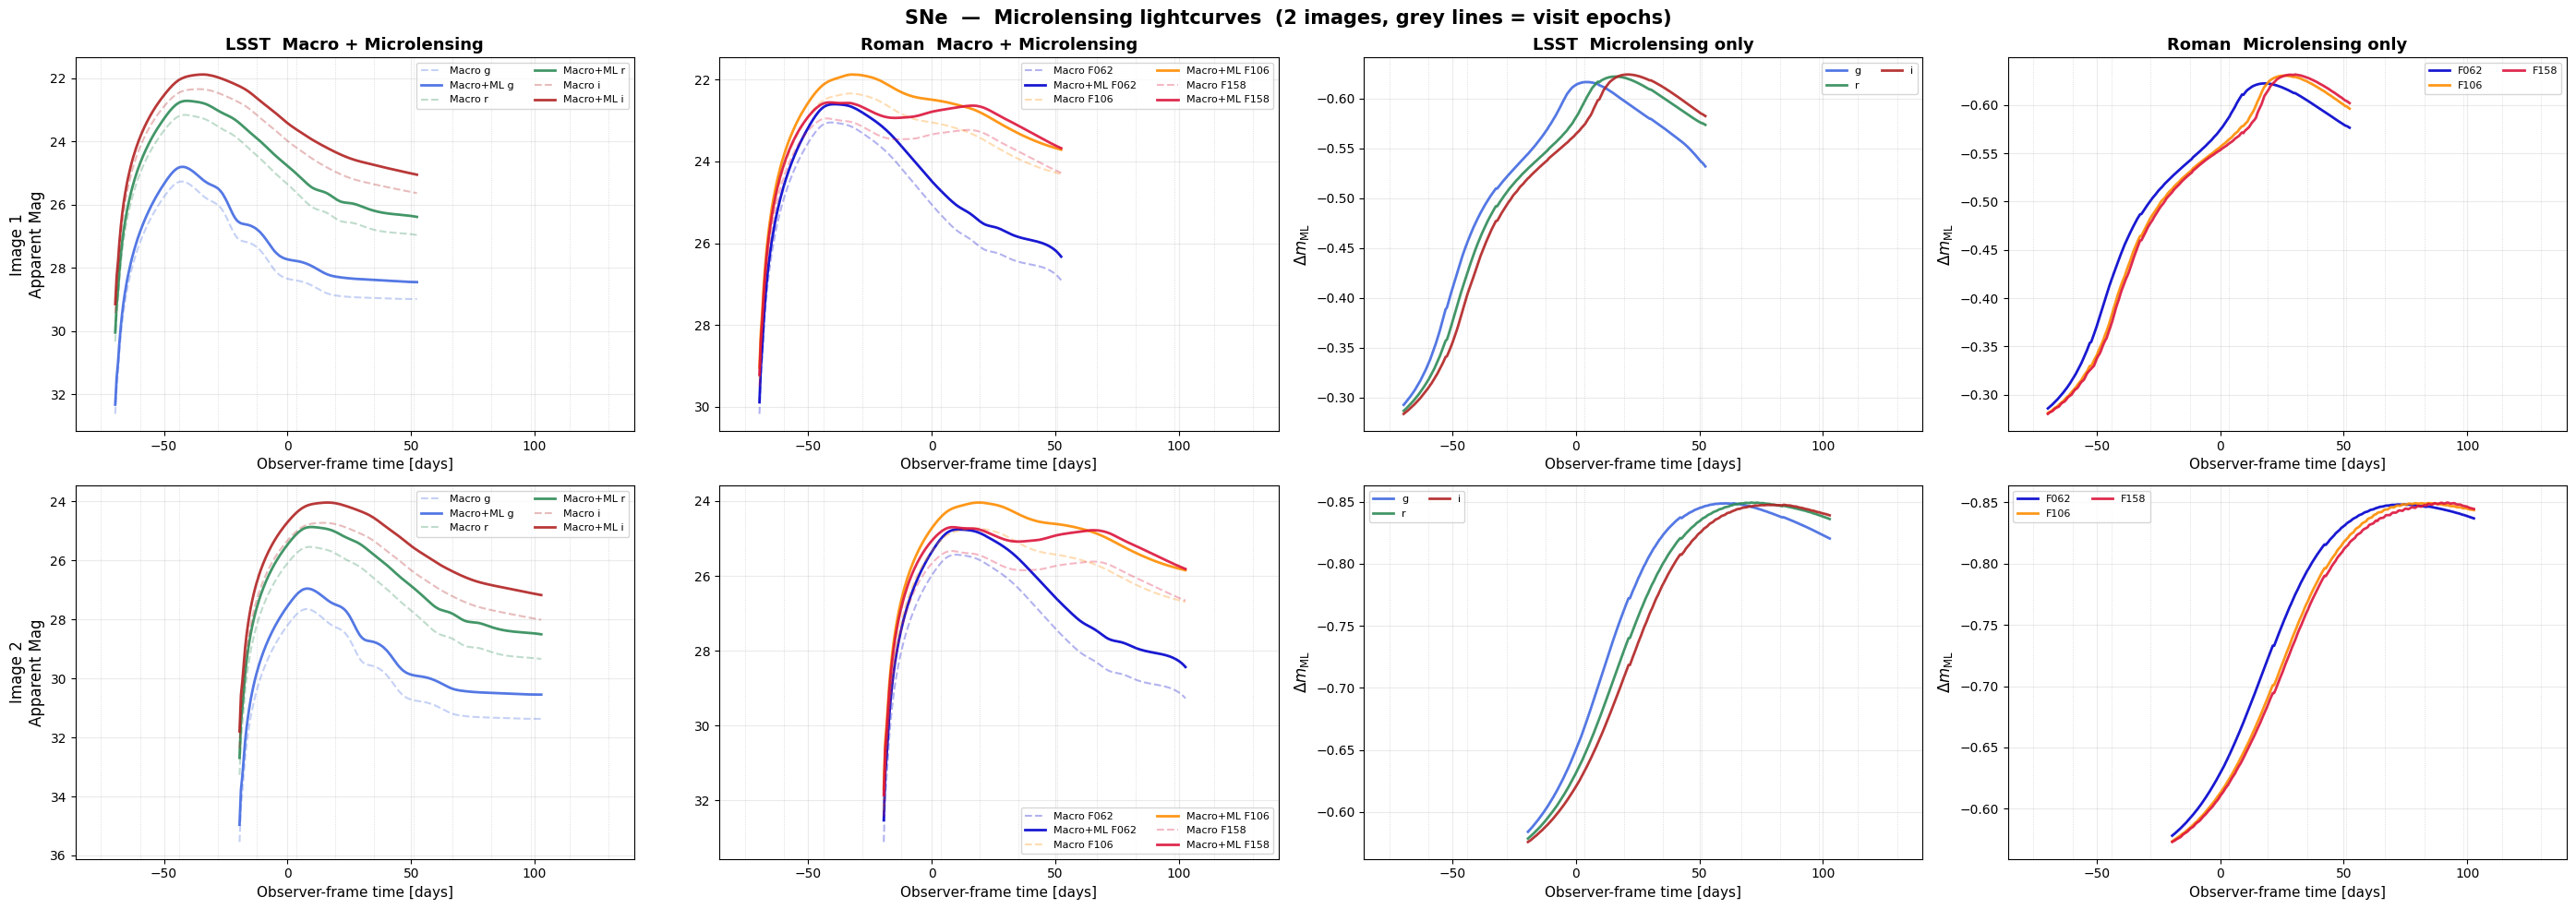

In [22]:
## 5. Lightcurve visualisation

colors = {
    "g": "royalblue",
    "r": "seagreen",
    "i": "firebrick",
    "F062": "mediumblue",
    "F106": "darkorange",
    "F158": "crimson",
}

fig, axes = plt.subplots(num_images, 4, figsize=(28, 5 * num_images))
if num_images == 1:
    axes = np.atleast_2d(axes)

for i in range(num_images):
    ax_lsst, ax_roman, ax_lsst_ml, ax_roman_ml = axes[i]

    for band in LSST_BANDS:
        c = colors[band]
        ax_lsst.plot(
            lc_times,
            lsst_macro[band][i],
            color=c,
            lw=1.5,
            ls="--",
            alpha=0.3,
            label=f"Macro {band}",
        )
        ax_lsst.plot(
            lc_times,
            lsst_micro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=f"Macro+ML {band}",
        )
        ax_lsst_ml.plot(
            lc_times,
            lsst_micro[band][i] - lsst_macro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=band,
        )

    for band in ROMAN_BANDS:
        c = colors[band]
        ax_roman.plot(
            lc_times,
            roman_macro[band][i],
            color=c,
            lw=1.5,
            ls="--",
            alpha=0.3,
            label=f"Macro {band}",
        )
        ax_roman.plot(
            lc_times,
            roman_micro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=f"Macro+ML {band}",
        )
        ax_roman_ml.plot(
            lc_times,
            roman_micro[band][i] - roman_macro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=band,
        )

    # Mark visit epochs
    for t in t_obs_visits:
        for ax in axes[i]:
            ax.axvline(t, color="grey", lw=0.6, alpha=0.35, ls=":")

    for ax in [ax_lsst, ax_roman]:
        ax.invert_yaxis()
    for ax in axes[i]:
        ax.set_xlabel("Observer-frame time [days]", fontsize=11)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.25)

    ax_lsst.set_ylabel(f"Image {i+1}\nApparent Mag", fontsize=12)
    ax_lsst_ml.set_ylabel(r"$\Delta m_{\rm ML}$", fontsize=12)
    ax_roman_ml.set_ylabel(r"$\Delta m_{\rm ML}$", fontsize=12)

    if i == 0:
        ax_lsst.set_title("LSST  Macro + Microlensing", fontsize=13, fontweight="bold")
        ax_roman.set_title(
            "Roman  Macro + Microlensing", fontsize=13, fontweight="bold"
        )
        ax_lsst_ml.set_title("LSST  Microlensing only", fontsize=13, fontweight="bold")
        ax_roman_ml.set_title(
            "Roman  Microlensing only", fontsize=13, fontweight="bold"
        )

    ax_lsst_ml.invert_yaxis()
    ax_roman_ml.invert_yaxis()


plt.suptitle(
    f"{SOURCE_TYPE}  —  Microlensing lightcurves  "
    f"({num_images} images, grey lines = visit epochs)",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Simulating 14 LSST i-band single-visit images …


/global/u1/s/sharma/repos/self/slsim/slsim/Microlensing/lightcurve.py:179: UserWarning: Source smaller than one magnification map pixel; treating as a point source.
  return self._generate_lightcurves(
/global/u1/s/sharma/repos/self/slsim/slsim/Microlensing/lightcurve.py:393: RuntimeWarning: divide by zero encountered in log10
  light_curve = -2.5 * np.log10(


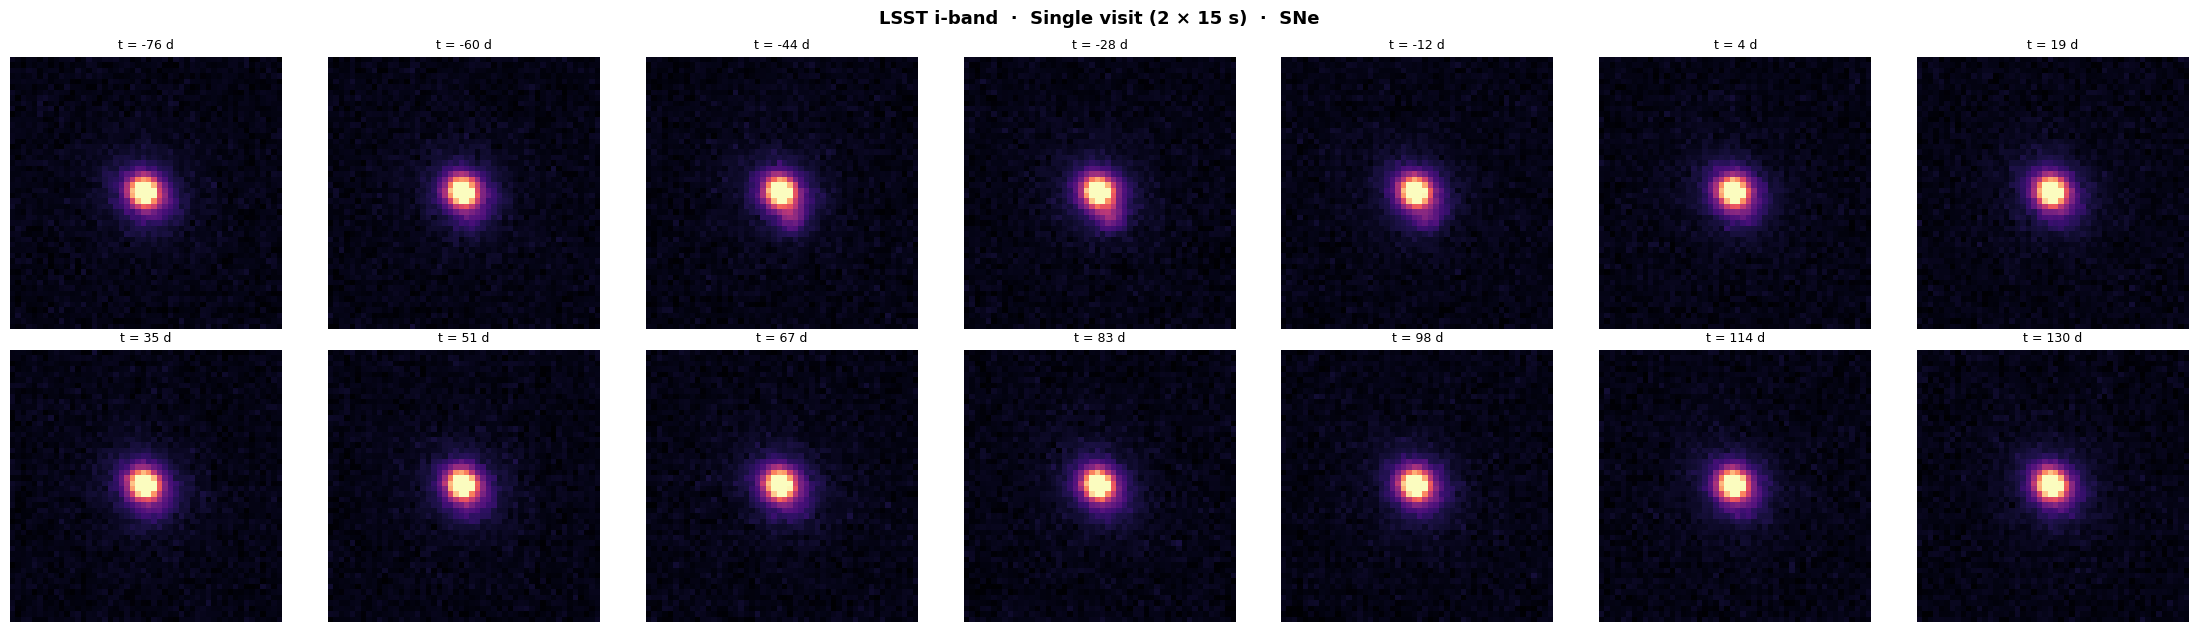

In [11]:
## 6. LSST single-visit image time series
# A single LSST visit is 2 × 15 s snaps (30 s total).  We override the
# coadded defaults by passing exposure_time and num_exposures directly.

NUM_PIX_LSST = 50
print(f"\nSimulating {len(t_obs_visits)} LSST {VIS_BAND}-band single-visit images …")

kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = VIS_BAND
lsst_visit_images = []
for t in t_obs_visits:
    img = simulate_image(
        lens_class,
        band=VIS_BAND,
        num_pix=NUM_PIX_LSST,
        add_noise=True,
        add_background_counts=False,
        observatory="LSST",
        t_obs=t,
        exposure_time=15,  # two 15 s snaps
        num_exposures=2,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )
    lsst_visit_images.append(img)

n_cols = min(7, len(t_obs_visits))
n_rows = int(np.ceil(len(t_obs_visits) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.array(axes).flatten()

stack = np.stack(lsst_visit_images)
vmin, vmax = np.percentile(stack, 1), np.percentile(stack, 99.5)

for idx, (img, t) in enumerate(zip(lsst_visit_images, t_obs_visits)):
    ax = axes[idx]
    ax.imshow(img, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t:.0f} d", fontsize=9)
    ax.axis("off")
for ax in axes[len(lsst_visit_images) :]:
    ax.axis("off")

plt.suptitle(
    f"LSST {VIS_BAND}-band  ·  Single visit (2 × 15 s)  ·  {SOURCE_TYPE}",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Precomputing 10 Roman F106 background maps …


/global/homes/s/sharma/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


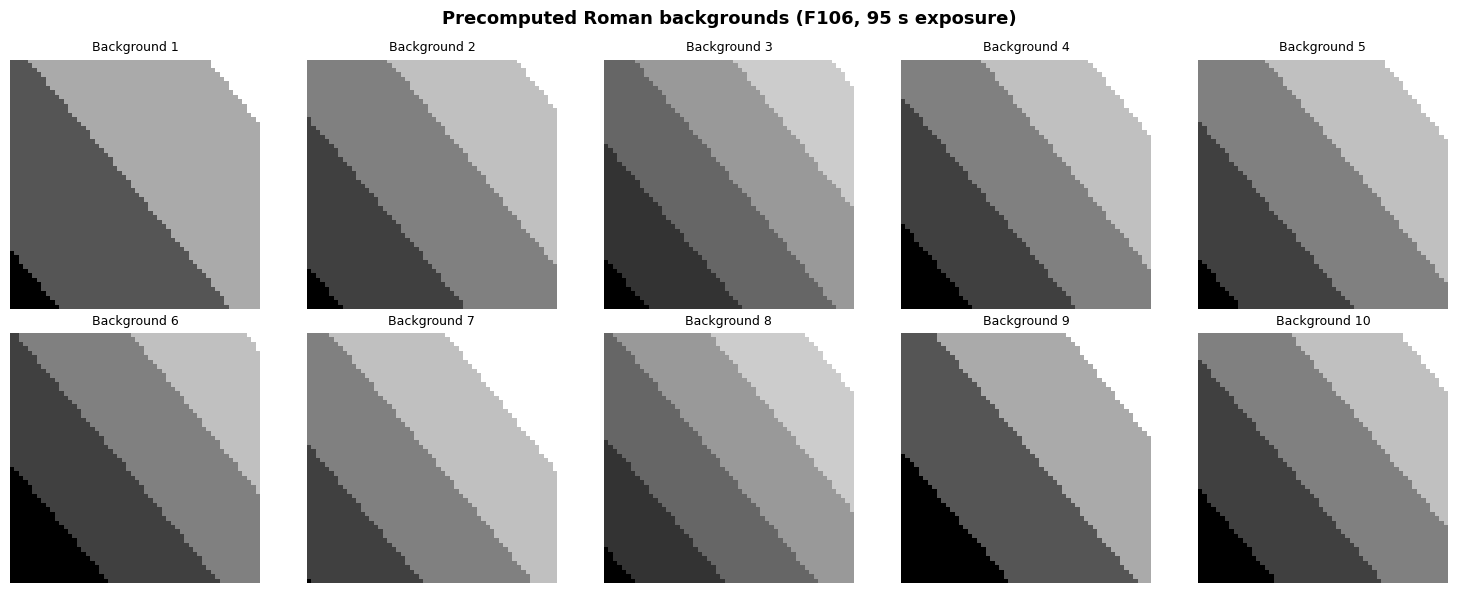

In [8]:
## 7. Roman background precomputation
# Precompute N_BG background maps.

# ------------------------------------------------------------------
# Adjust ROMAN_PSF_DIR to the directory containing cached PSF files.
# If None, simulate_roman_image generates PSFs on-the-fly (very slow).
# ------------------------------------------------------------------
ROMAN_PSF_DIR = "/global/homes/s/sharma/repos/self/slsim/tests/TestData"  # e.g. "/path/to/stpsf_cache"

NUM_PIX_ROMAN = 50

N_BG = 10
ref_date = datetime.datetime(year=2027, month=7, day=7, hour=0, minute=0, second=0)

print(f"\nPrecomputing {N_BG} Roman {ROMAN_VIS_BAND} background maps …")
roman_backgrounds = []
for k in range(N_BG):
    bg = precompute_roman_background(
        band=ROMAN_VIS_BAND,
        num_pix=50,
        exposure_time=ROMAN_EXPOSURE_TIME,
        detector=1,
        detector_pos=(2000, 2000),
    )
    roman_backgrounds.append(bg)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, bg in enumerate(roman_backgrounds):
    ax = axes.flatten()[idx]
    ax.imshow(bg, origin="lower", cmap="gray")
    ax.set_title(f"Background {idx+1}", fontsize=9)
    ax.axis("off")
plt.suptitle(
    "Precomputed Roman backgrounds (F106, 95 s exposure)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Simulating 14 Roman F106 single-visit images …


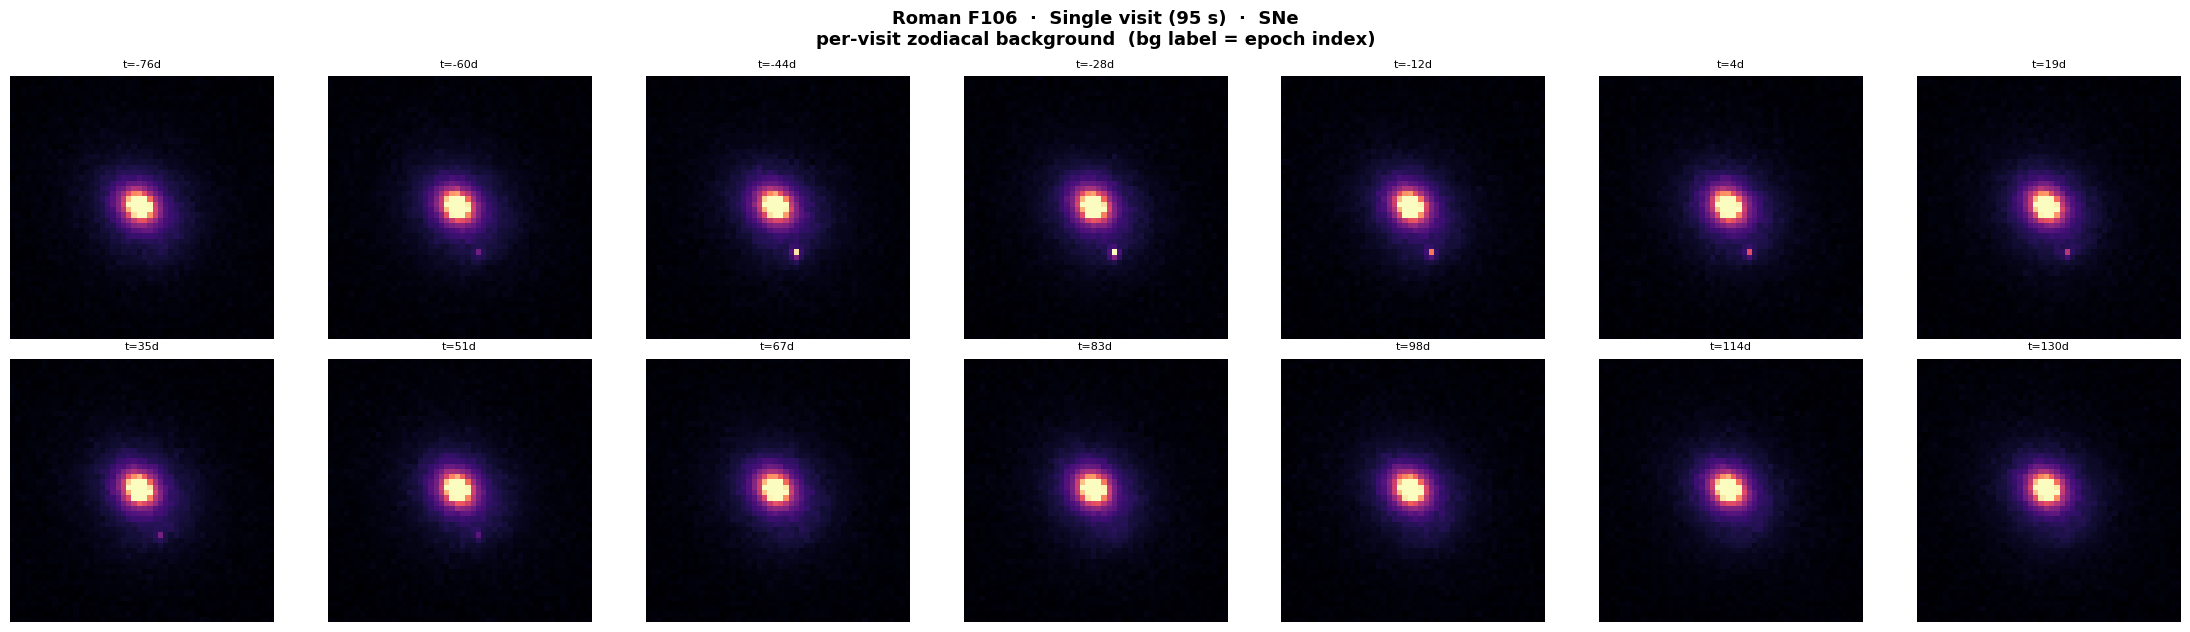

In [10]:
## 8. Roman single-visit image time series
# survey_mode="time_domain_wide" sets num_exposures=1 automatically.
# The precomputed background is injected via precomputed_background,
# skipping the expensive WCS / sky-level computation on every call.

print(
    f"\nSimulating {len(t_obs_visits)} Roman {ROMAN_VIS_BAND} " f"single-visit images …"
)

kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = ROMAN_VIS_BAND
roman_visit_images = []
for t in t_obs_visits:
    bg = roman_backgrounds[
        np.random.randint(0, N_BG)
    ]  # randomly assign one of the precomputed backgrounds to this visit
    img = simulate_roman_image(
        lens_class,
        band=ROMAN_VIS_BAND,
        num_pix=NUM_PIX_ROMAN,
        oversample=3,
        add_noise=True,
        subtract_mean_background=True,
        with_source=True,
        with_deflector=True,
        t_obs=t,
        survey_mode="time_domain_wide",  # num_exposures=1, exposure_time=95 s for F106
        detector=1,
        detector_pos=(2000, 2000),
        psf_directory=ROMAN_PSF_DIR,
        precomputed_background=bg,  # skip expensive sky recomputation
    )
    roman_visit_images.append(img)

n_cols = min(7, len(t_obs_visits))
n_rows = int(np.ceil(len(t_obs_visits) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.array(axes).flatten()

stack = np.stack(roman_visit_images)
vmin, vmax = np.percentile(stack, 1), np.percentile(stack, 99.5)

for idx, (img, t) in enumerate(zip(roman_visit_images, t_obs_visits)):
    ax = axes[idx]
    ax.imshow(img, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"t={t:.0f}d", fontsize=8)
    ax.axis("off")
for ax in axes[len(roman_visit_images) :]:
    ax.axis("off")

plt.suptitle(
    f"Roman {ROMAN_VIS_BAND}  ·  Single visit ({ROMAN_EXPOSURE_TIME} s)  ·  {SOURCE_TYPE}\n"
    f"per-visit zodiacal background  (bg label = epoch index)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

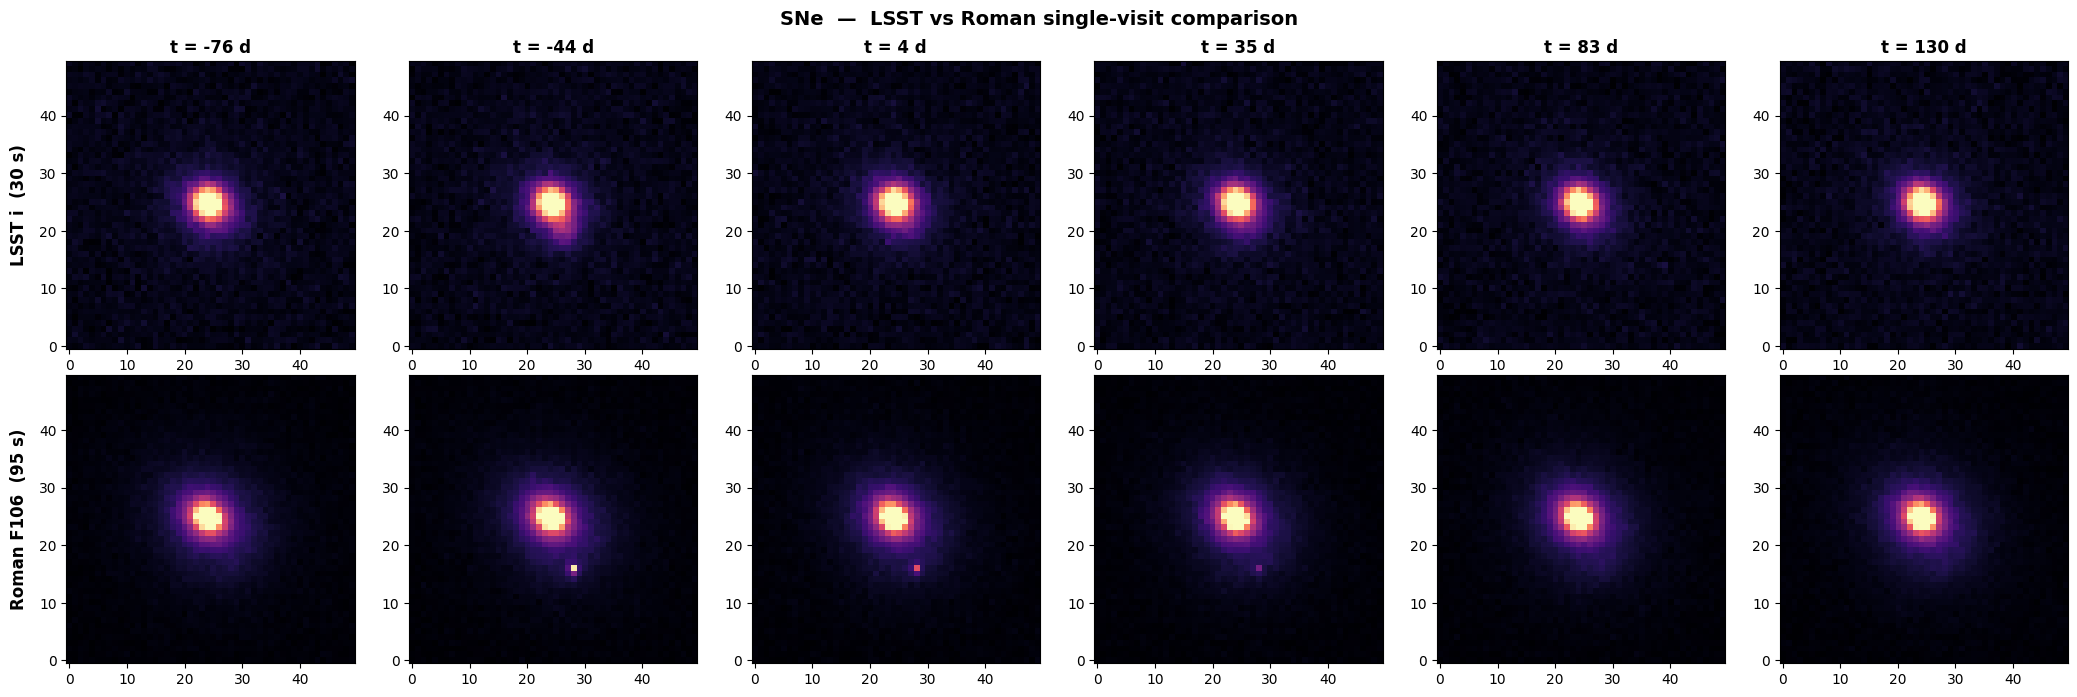

In [21]:
## 9. Side-by-side LSST vs Roman comparison at selected epochs

compare_indices = np.linspace(
    0, len(t_obs_visits) - 1, min(6, len(t_obs_visits)), dtype=int
)

fig, axes = plt.subplots(
    2, len(compare_indices), figsize=(3.5 * len(compare_indices), 7)
)

for col, idx in enumerate(compare_indices):
    t = t_obs_visits[idx]

    li = lsst_visit_images[idx]
    ri = roman_visit_images[idx]

    axes[0, col].imshow(
        li,
        origin="lower",
        cmap="magma",
        vmin=np.percentile(li, 1),
        vmax=np.percentile(li, 99.5),
    )
    axes[0, col].set_title(f"t = {t:.0f} d", fontsize=12, fontweight="bold")

    axes[1, col].imshow(
        ri,
        origin="lower",
        cmap="magma",
        vmin=np.percentile(ri, 1),
        vmax=np.percentile(ri, 99.5),
    )

axes[0, 0].set_ylabel(
    f"LSST {VIS_BAND}  (30 s)", fontsize=12, fontweight="bold", labelpad=8
)
axes[1, 0].set_ylabel(
    f"Roman {ROMAN_VIS_BAND}  ({ROMAN_EXPOSURE_TIME} s)",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

fig.suptitle(
    f"{SOURCE_TYPE}  —  LSST vs Roman single-visit comparison",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()

In [ ]:
# ---------------------------------------------------------------------------
# Optional: reset the microlensing track and rerun sections 4–9 to produce
# a different realisation of the microlensing signature.
#
# lens_class.reset_microlensing_model_class(0)
# ---------------------------------------------------------------------------

## Lensed AGN

In [2]:
## 1. Load pickled lens and detect source type

# ------------------------------------------------------------------
# Set PICKLE_PATH to the file saved by ERL_lensed_SNe_sims.ipynb
# or ERL_lensed_AGN_sims.ipynb.
# ------------------------------------------------------------------
PICKLE_PATH = "lens_agn.pkl"

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

with open(PICKLE_PATH, "rb") as f:
    lens_class = pickle.load(f)

# Detect source type from name stored in the Source class
source_name = lens_class.max_redshift_source_class.name
IS_SNE = source_name.startswith("SN")
SOURCE_TYPE = "SNe" if IS_SNE else "AGN"

print(f"Loaded {SOURCE_TYPE} lens  ({source_name})")
print(f"  Deflector z  = {lens_class.deflector_redshift:.4f}")
print(f"  Source z     = {lens_class.source_redshift_list[0]:.4f}")
print(f"  Einstein R   = {lens_class.einstein_radius[0]:.4f} arcsec")
print(f"  N images     = {lens_class.image_number[0]}")

Loaded AGN lens  (QSO)
  Deflector z  = 1.7610
  Source z     = 2.5316
  Einstein R   = 0.7071 arcsec
  N images     = 4


In [3]:
## 2. Observation planning

# Arrival-time corrected observation window
arrival_times = lens_class.point_source_arrival_times()[0]
t_ref = np.max(arrival_times)

if IS_SNE:
    # Cover the full SN light curve with ~14 visits
    t_start = float(np.min(arrival_times) - t_ref - 25)
    t_end = float(np.max(arrival_times) - t_ref + 130)
    t_obs_visits = np.linspace(t_start, t_end, 14)
    lc_times = np.linspace(t_start - 10, t_end + 10, 400)
    LSST_BANDS = ["g", "r", "i"]
    ROMAN_BANDS = ["F062", "F106", "F158"]
    VIS_BAND = "i"
    ROMAN_VIS_BAND = "F106"
    ROMAN_EXPOSURE_TIME = 95  # F106 time_domain_wide single visit [s]
else:
    # Cover ~3 years of AGN variability with ~15 visits
    t_start = 0.0
    t_end = 1200.0
    t_obs_visits = np.linspace(t_start, t_end, 15)
    lc_times = np.linspace(-50, t_end + 50, 1300)
    LSST_BANDS = ["g", "r", "i"]
    ROMAN_BANDS = ["F062", "F106", "F158"]
    VIS_BAND = "i"
    ROMAN_VIS_BAND = "F106"
    ROMAN_EXPOSURE_TIME = 95

print(
    f"\nObservation window : {t_start:.1f} to {t_end:.1f} days "
    f"({len(t_obs_visits)} visits)"
)
print(f"Visit cadence      : {(t_end-t_start)/(len(t_obs_visits)-1):.1f} days")


Observation window : 0.0 to 1200.0 days (15 visits)
Visit cadence      : 85.7 days


In [ ]:
## 3. Microlensing setup

theta_E_micro_arcsec, _, _ = theta_star_physical(
    z_lens=lens_class.deflector_redshift,
    z_src=lens_class.source_redshift_list[0],
    cosmo=cosmo,
    m=1.0,
)
theta_E_micro = theta_E_micro_arcsec.value

kwargs_micro = {
    "kwargs_magnification_map": {
        "theta_star": theta_E_micro,
        "half_length_x": 1.5 * theta_E_micro,
        "half_length_y": 1.5 * theta_E_micro,
        "num_pixels_x": 1000,
        "num_pixels_y": 1000,
    },
    "kwargs_source_morphology": {},  # will be updated internally
}

In [5]:
## 4. Compute lightcurves across LSST and Roman bands
# The first microlensing call builds the magnification map (~10 s per image).
# All subsequent calls reuse it.  The microlensing track initialised here is
# the same one used when simulating the visit images in later sections.

print("Computing LSST lightcurves …")
lsst_macro, lsst_micro = {}, {}
for band in LSST_BANDS:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    lsst_macro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=False,
    )[0]
    lsst_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]
    print(f"  {band} done")

print("Computing Roman lightcurves …")
roman_macro, roman_micro = {}, {}
for band in ROMAN_BANDS:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    roman_macro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=False,
    )[0]
    roman_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=lc_times,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]
    print(f"  {band} done")

num_images = lens_class.image_number[0]

Computing LSST lightcurves …


/global/homes/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/homes/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/homes/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.


/global/homes/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


  g done
  r done
  i done
Computing Roman lightcurves …
  F062 done
  F106 done
  F158 done


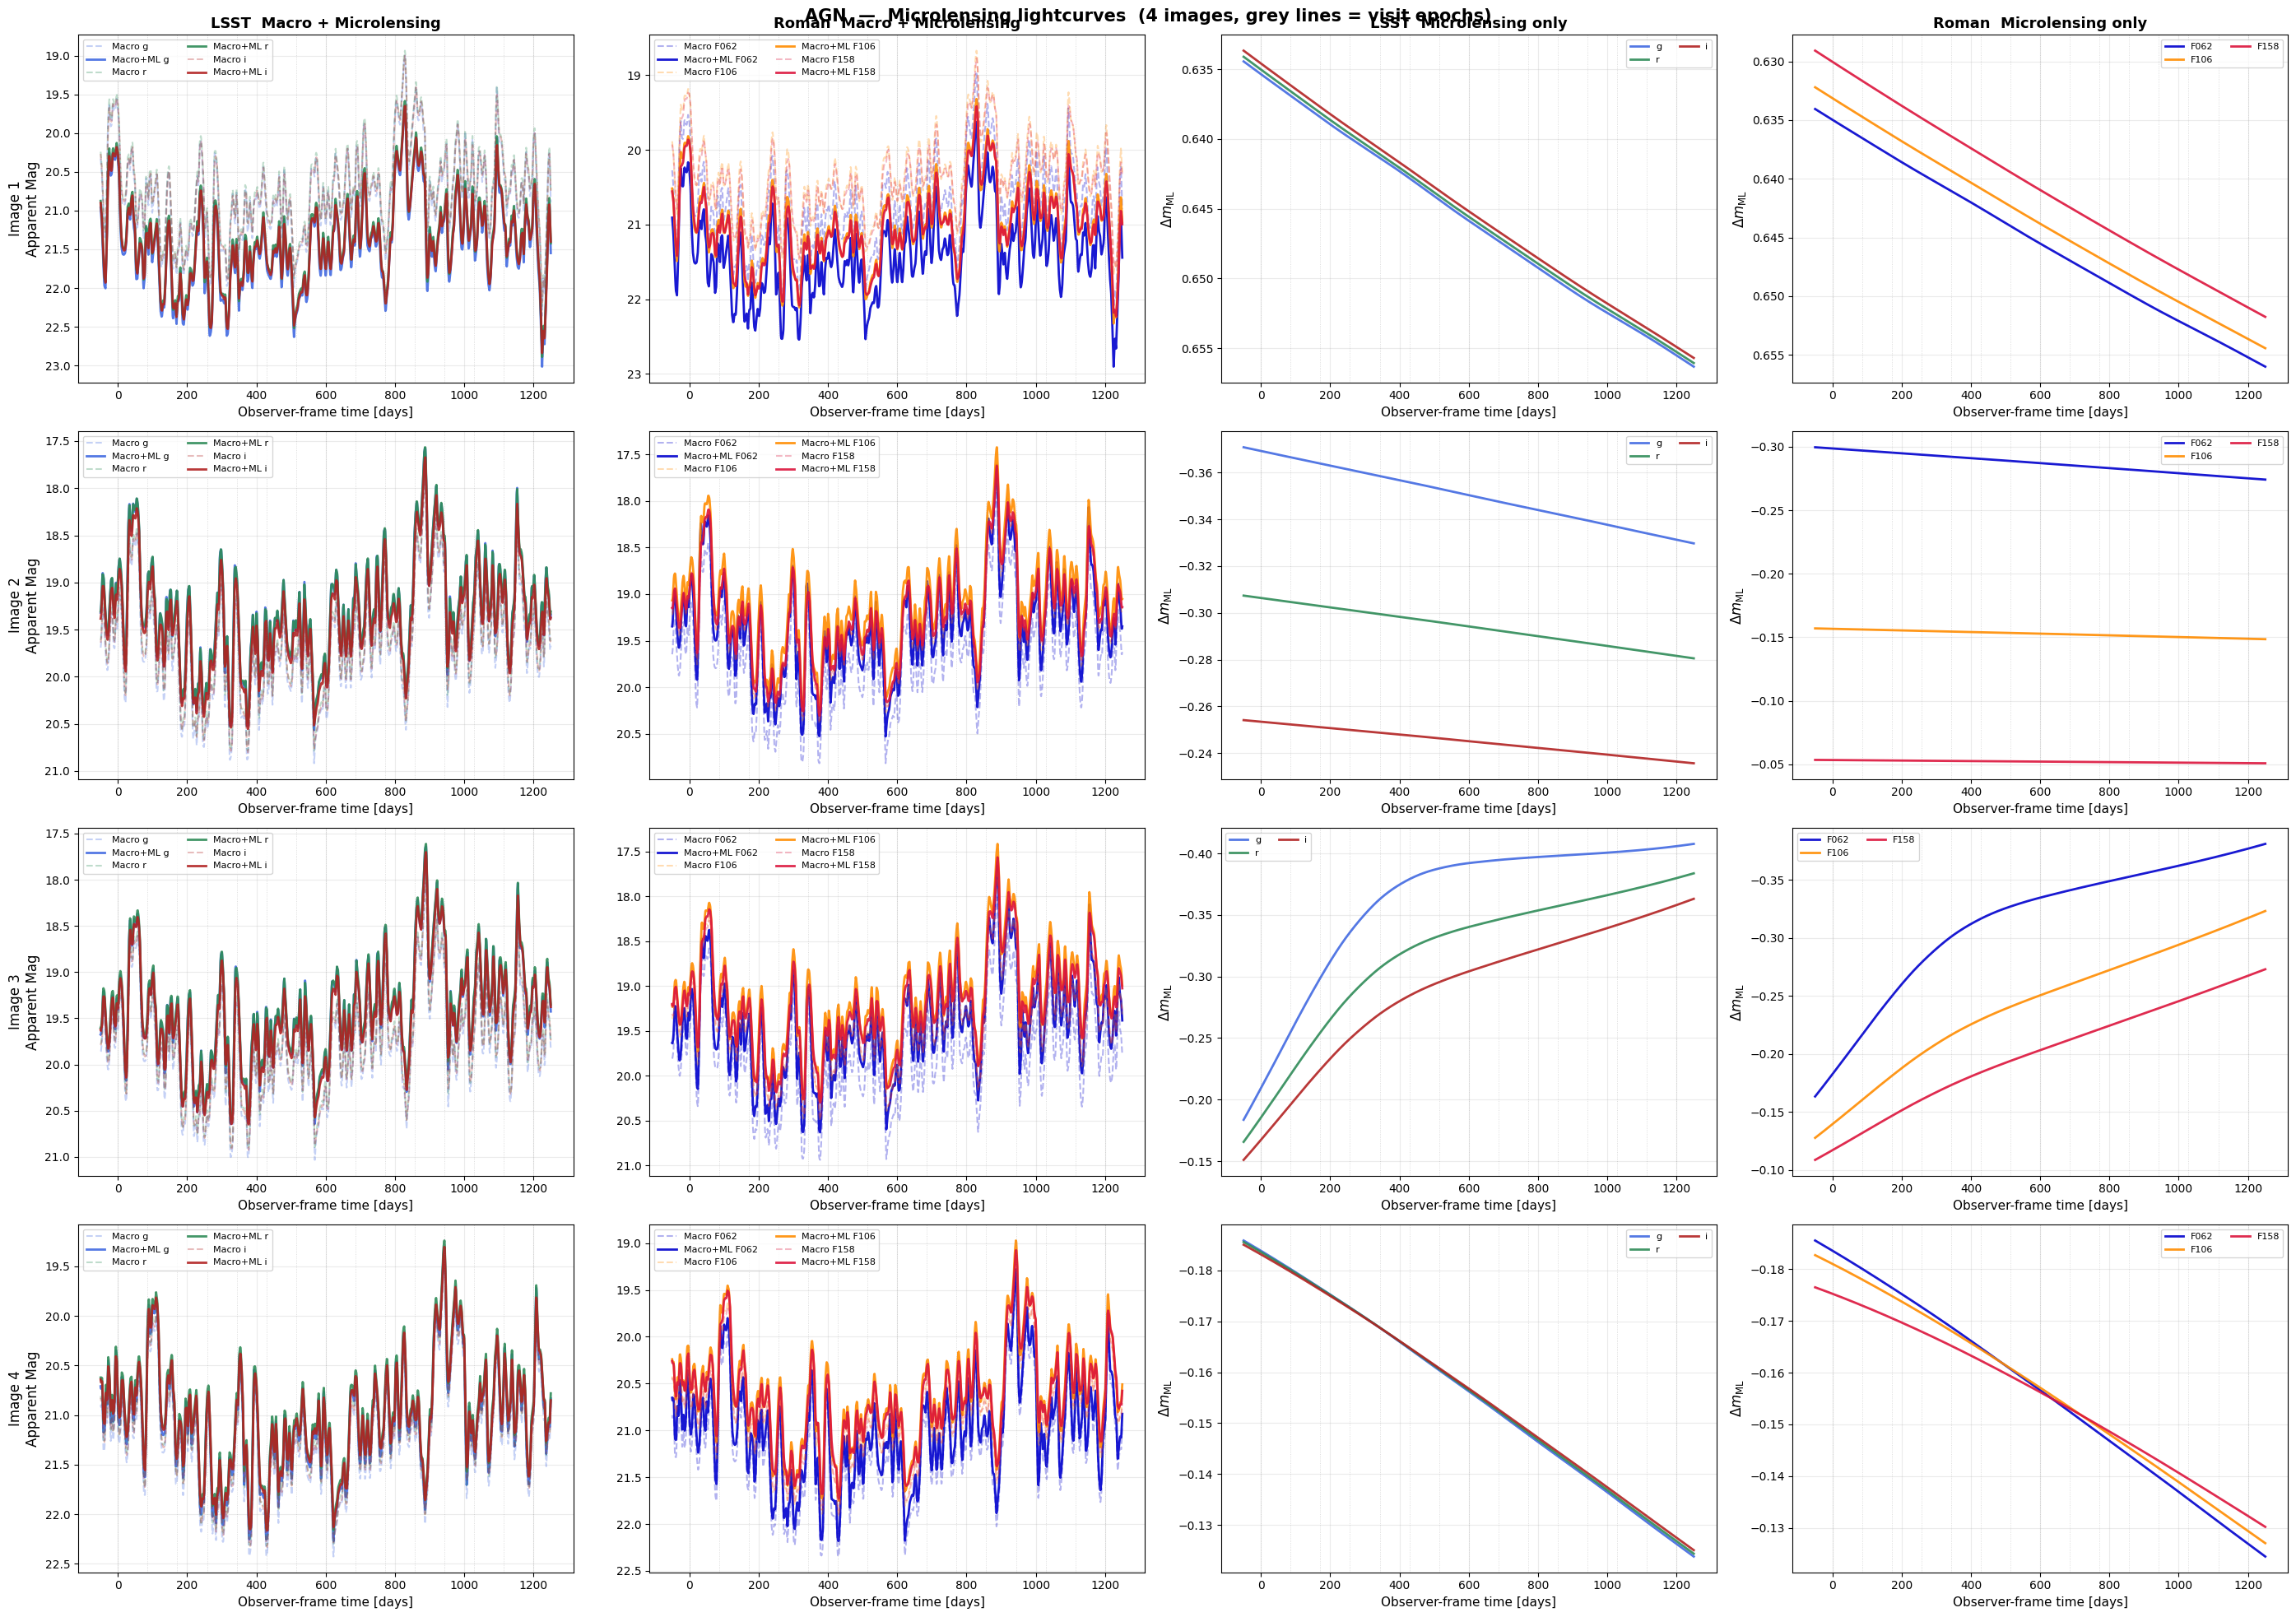

In [6]:
## 5. Lightcurve visualisation

colors = {
    "g": "royalblue",
    "r": "seagreen",
    "i": "firebrick",
    "F062": "mediumblue",
    "F106": "darkorange",
    "F158": "crimson",
}

fig, axes = plt.subplots(num_images, 4, figsize=(28, 5 * num_images))
if num_images == 1:
    axes = np.atleast_2d(axes)

for i in range(num_images):
    ax_lsst, ax_roman, ax_lsst_ml, ax_roman_ml = axes[i]

    for band in LSST_BANDS:
        c = colors[band]
        ax_lsst.plot(
            lc_times,
            lsst_macro[band][i],
            color=c,
            lw=1.5,
            ls="--",
            alpha=0.3,
            label=f"Macro {band}",
        )
        ax_lsst.plot(
            lc_times,
            lsst_micro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=f"Macro+ML {band}",
        )
        ax_lsst_ml.plot(
            lc_times,
            lsst_micro[band][i] - lsst_macro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=band,
        )

    for band in ROMAN_BANDS:
        c = colors[band]
        ax_roman.plot(
            lc_times,
            roman_macro[band][i],
            color=c,
            lw=1.5,
            ls="--",
            alpha=0.3,
            label=f"Macro {band}",
        )
        ax_roman.plot(
            lc_times,
            roman_micro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=f"Macro+ML {band}",
        )
        ax_roman_ml.plot(
            lc_times,
            roman_micro[band][i] - roman_macro[band][i],
            color=c,
            lw=2,
            alpha=0.9,
            label=band,
        )

    # Mark visit epochs
    for t in t_obs_visits:
        for ax in axes[i]:
            ax.axvline(t, color="grey", lw=0.6, alpha=0.35, ls=":")

    for ax in [ax_lsst, ax_roman]:
        ax.invert_yaxis()
    for ax in axes[i]:
        ax.set_xlabel("Observer-frame time [days]", fontsize=11)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.25)

    ax_lsst.set_ylabel(f"Image {i+1}\nApparent Mag", fontsize=12)
    ax_lsst_ml.set_ylabel(r"$\Delta m_{\rm ML}$", fontsize=12)
    ax_roman_ml.set_ylabel(r"$\Delta m_{\rm ML}$", fontsize=12)

    if i == 0:
        ax_lsst.set_title("LSST  Macro + Microlensing", fontsize=13, fontweight="bold")
        ax_roman.set_title(
            "Roman  Macro + Microlensing", fontsize=13, fontweight="bold"
        )
        ax_lsst_ml.set_title("LSST  Microlensing only", fontsize=13, fontweight="bold")
        ax_roman_ml.set_title(
            "Roman  Microlensing only", fontsize=13, fontweight="bold"
        )

    ax_lsst_ml.invert_yaxis()
    ax_roman_ml.invert_yaxis()


plt.suptitle(
    f"{SOURCE_TYPE}  —  Microlensing lightcurves  "
    f"({num_images} images, grey lines = visit epochs)",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Simulating 15 LSST i-band single-visit images …


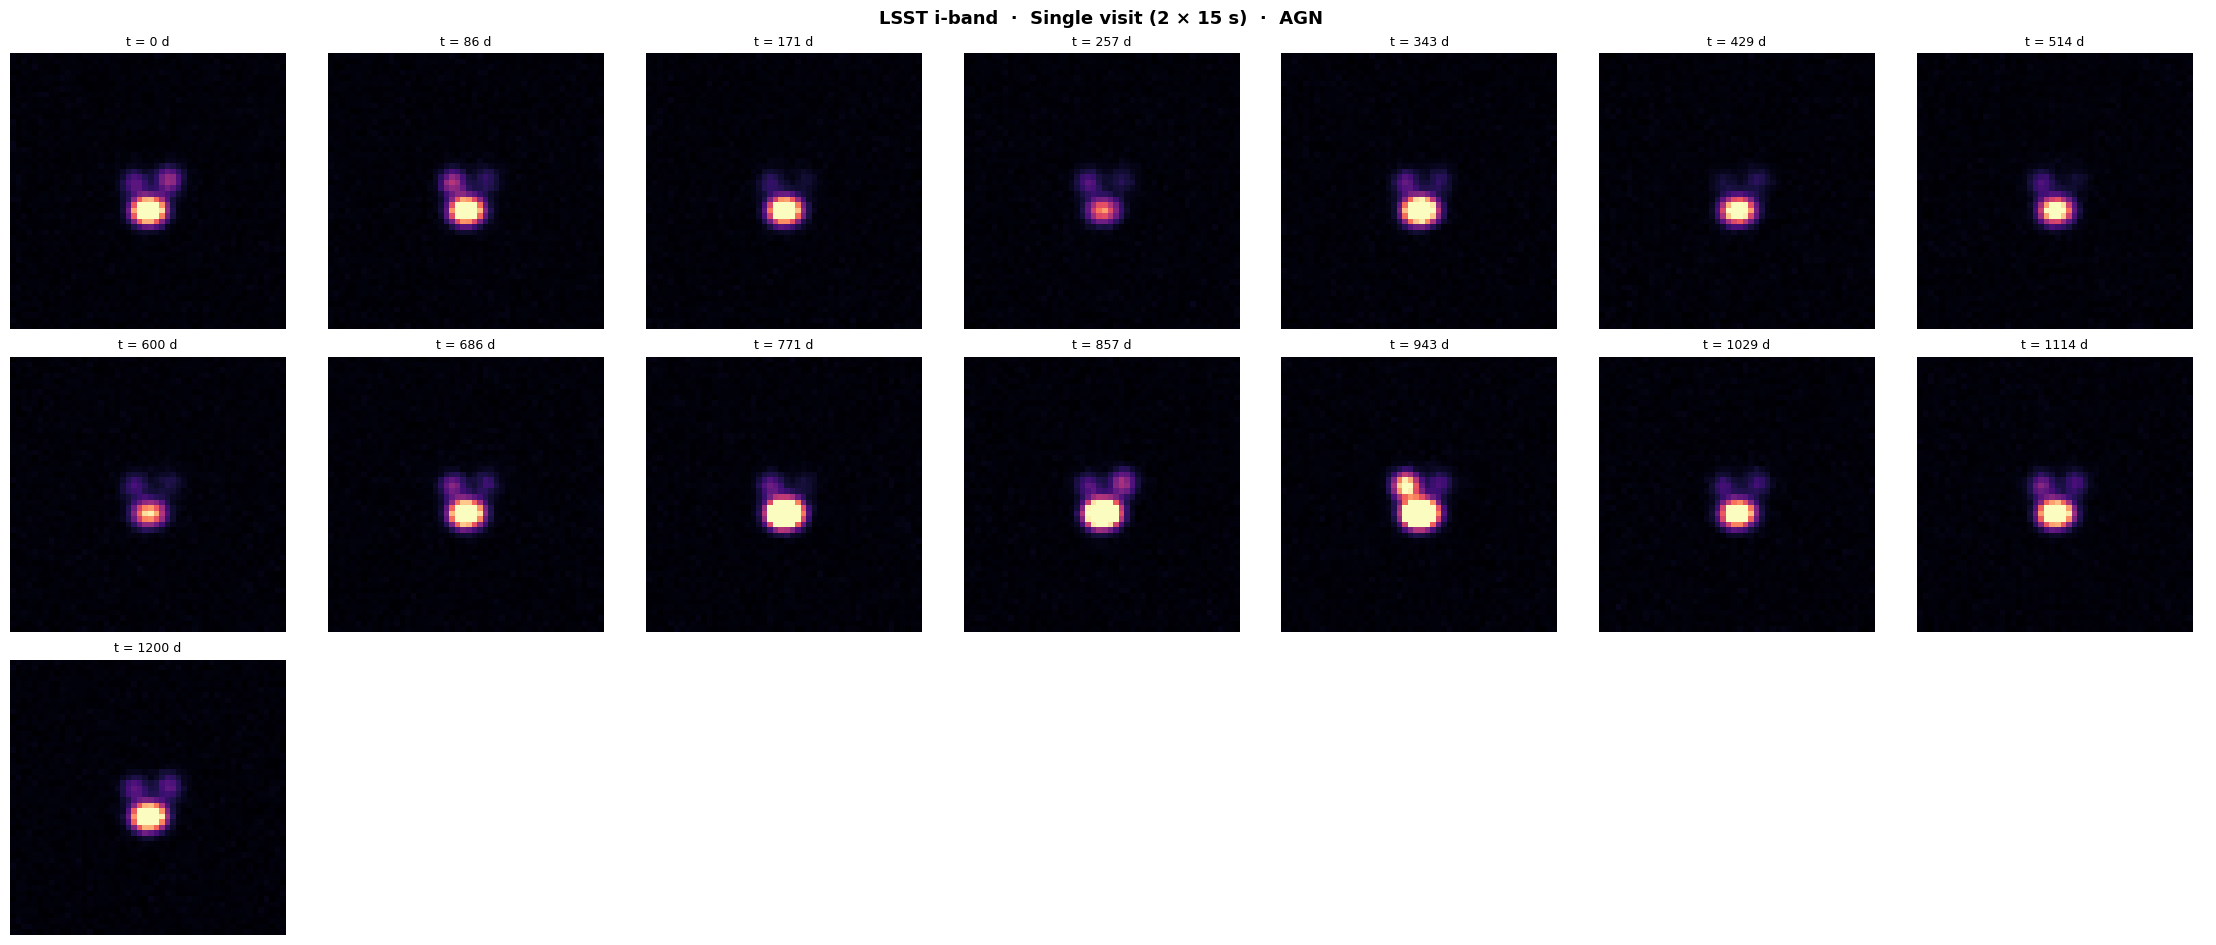

In [7]:
## 6. LSST single-visit image time series
# A single LSST visit is 2 × 15 s snaps (30 s total).  We override the
# coadded defaults by passing exposure_time and num_exposures directly.

NUM_PIX_LSST = 50
print(f"\nSimulating {len(t_obs_visits)} LSST {VIS_BAND}-band single-visit images …")

kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = VIS_BAND
lsst_visit_images = []
for t in t_obs_visits:
    img = simulate_image(
        lens_class,
        band=VIS_BAND,
        num_pix=NUM_PIX_LSST,
        add_noise=True,
        add_background_counts=False,
        observatory="LSST",
        t_obs=t,
        exposure_time=15,  # two 15 s snaps
        num_exposures=2,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )
    lsst_visit_images.append(img)

n_cols = min(7, len(t_obs_visits))
n_rows = int(np.ceil(len(t_obs_visits) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.array(axes).flatten()

stack = np.stack(lsst_visit_images)
vmin, vmax = np.percentile(stack, 1), np.percentile(stack, 99.5)

for idx, (img, t) in enumerate(zip(lsst_visit_images, t_obs_visits)):
    ax = axes[idx]
    ax.imshow(img, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t:.0f} d", fontsize=9)
    ax.axis("off")
for ax in axes[len(lsst_visit_images) :]:
    ax.axis("off")

plt.suptitle(
    f"LSST {VIS_BAND}-band  ·  Single visit (2 × 15 s)  ·  {SOURCE_TYPE}",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Precomputing 10 Roman F106 background maps …


/global/homes/s/sharma/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


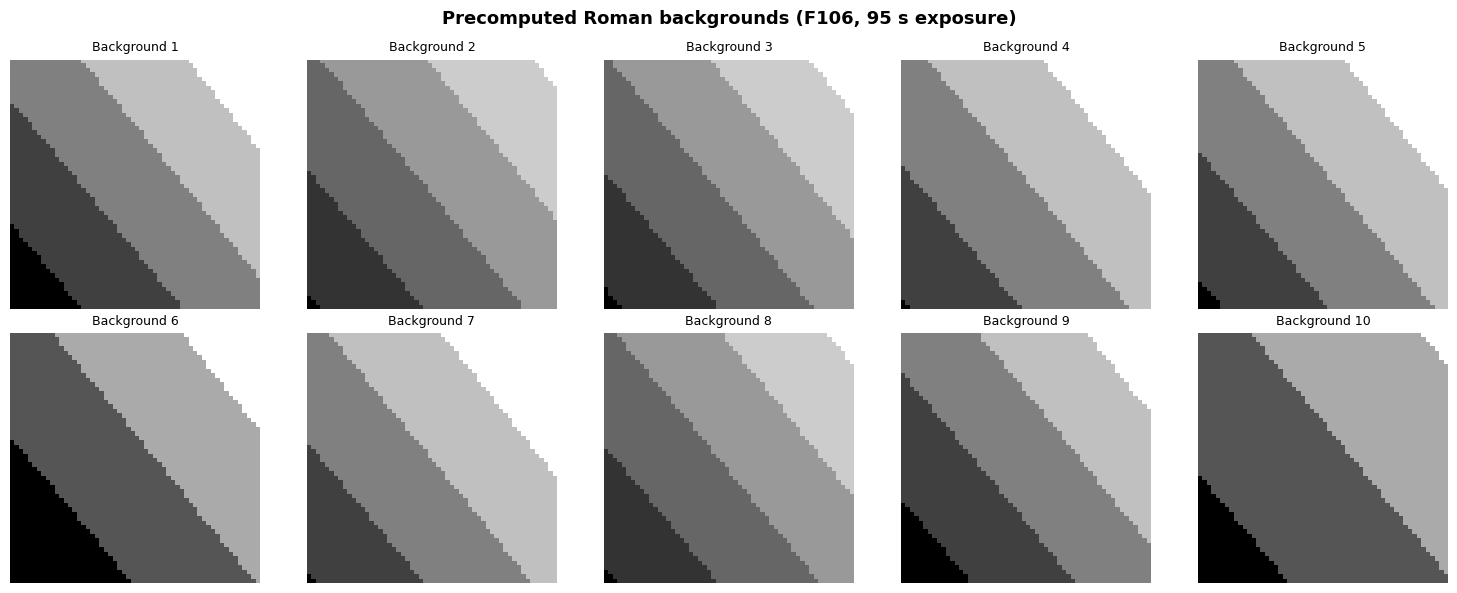

In [8]:
## 7. Roman background precomputation
# Precompute N_BG background maps.

# ------------------------------------------------------------------
# Adjust ROMAN_PSF_DIR to the directory containing cached PSF files.
# If None, simulate_roman_image generates PSFs on-the-fly (very slow).
# ------------------------------------------------------------------
ROMAN_PSF_DIR = "/global/homes/s/sharma/repos/self/slsim/tests/TestData"  # e.g. "/path/to/stpsf_cache"

NUM_PIX_ROMAN = 50

N_BG = 10
ref_date = datetime.datetime(year=2027, month=7, day=7, hour=0, minute=0, second=0)

print(f"\nPrecomputing {N_BG} Roman {ROMAN_VIS_BAND} background maps …")
roman_backgrounds = []
for k in range(N_BG):
    bg = precompute_roman_background(
        band=ROMAN_VIS_BAND,
        num_pix=50,
        exposure_time=ROMAN_EXPOSURE_TIME,
        detector=1,
        detector_pos=(2000, 2000),
    )
    roman_backgrounds.append(bg)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, bg in enumerate(roman_backgrounds):
    ax = axes.flatten()[idx]
    ax.imshow(bg, origin="lower", cmap="gray")
    ax.set_title(f"Background {idx+1}", fontsize=9)
    ax.axis("off")
plt.suptitle(
    "Precomputed Roman backgrounds (F106, 95 s exposure)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Simulating 15 Roman F106 single-visit images …


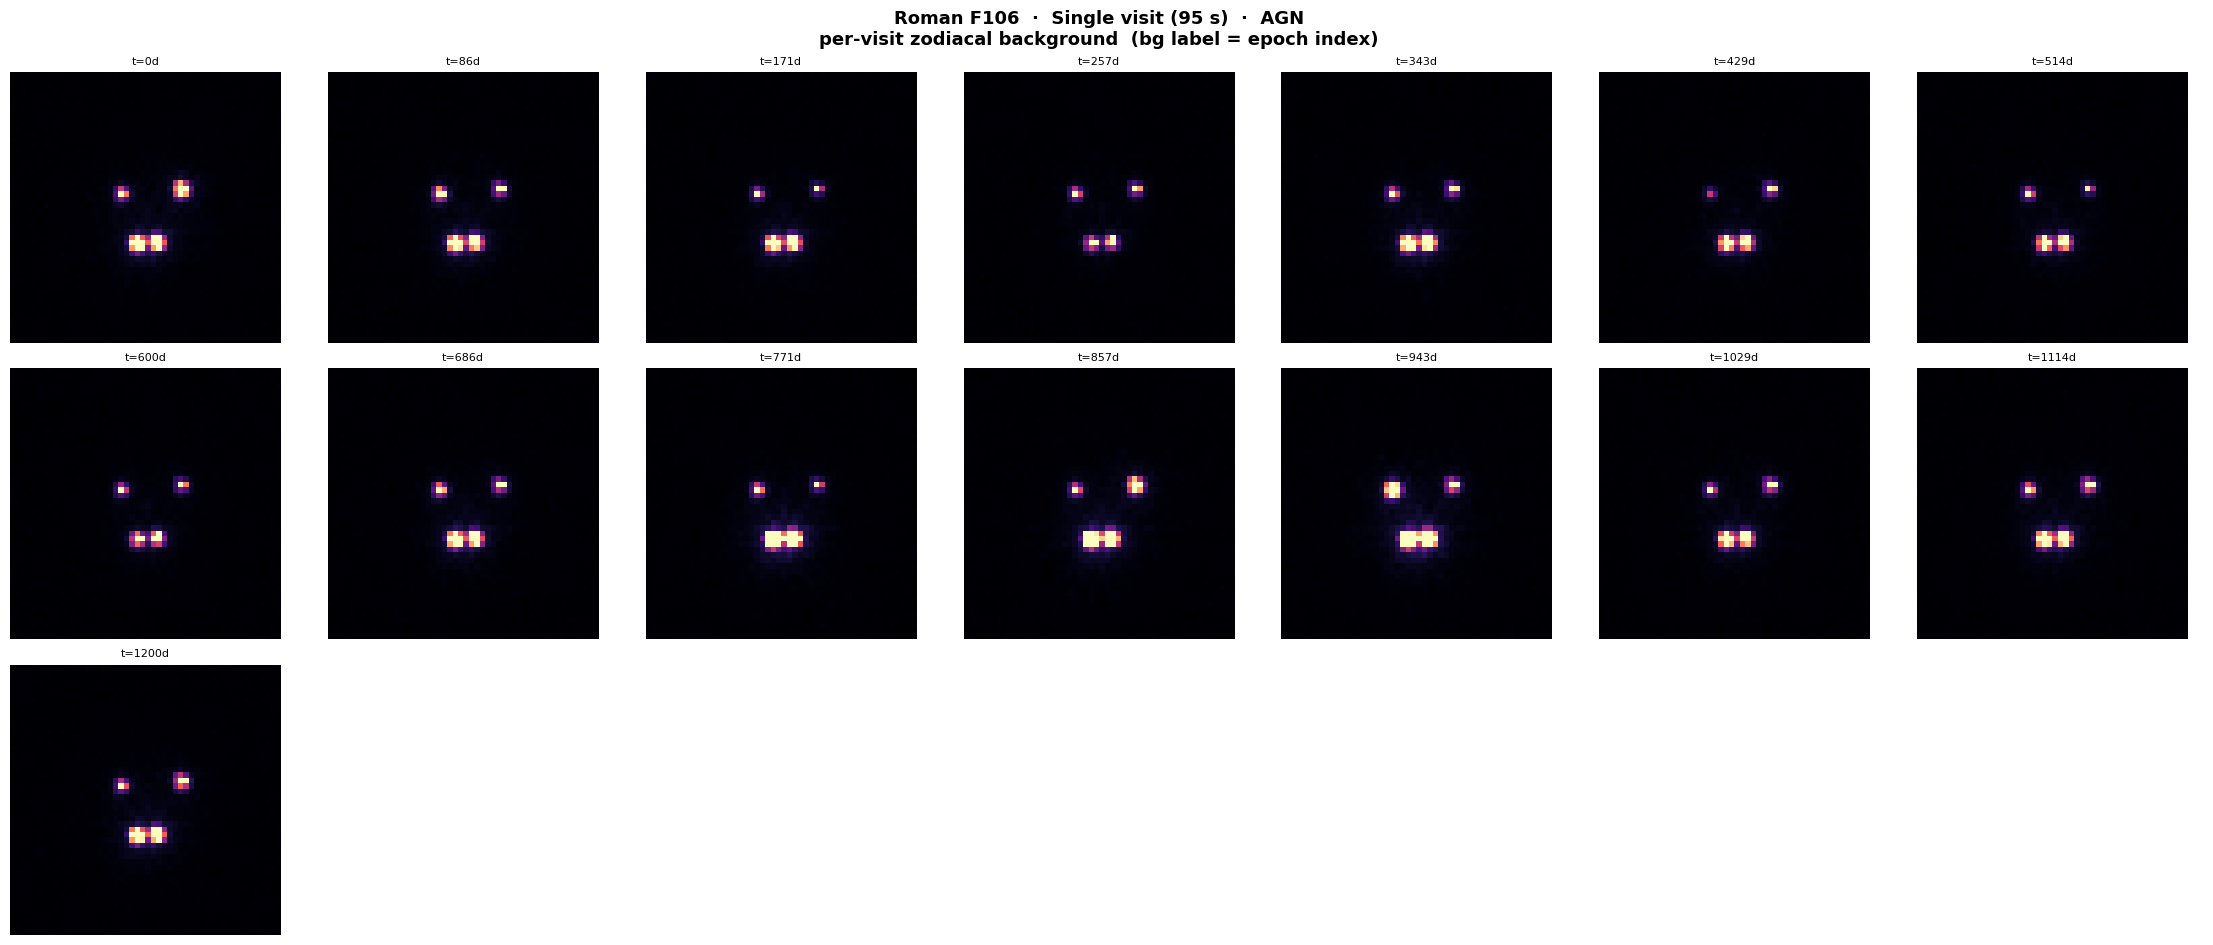

In [9]:
## 8. Roman single-visit image time series
# survey_mode="time_domain_wide" sets num_exposures=1 automatically.
# The precomputed background is injected via precomputed_background,
# skipping the expensive WCS / sky-level computation on every call.

print(
    f"\nSimulating {len(t_obs_visits)} Roman {ROMAN_VIS_BAND} " f"single-visit images …"
)

kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = ROMAN_VIS_BAND
roman_visit_images = []
for t in t_obs_visits:
    bg = roman_backgrounds[
        np.random.randint(0, N_BG)
    ]  # randomly assign one of the precomputed backgrounds to this visit
    img = simulate_roman_image(
        lens_class,
        band=ROMAN_VIS_BAND,
        num_pix=NUM_PIX_ROMAN,
        oversample=3,
        add_noise=True,
        subtract_mean_background=True,
        with_source=True,
        with_deflector=True,
        t_obs=t,
        survey_mode="time_domain_wide",  # num_exposures=1, exposure_time=95 s for F106
        detector=1,
        detector_pos=(2000, 2000),
        psf_directory=ROMAN_PSF_DIR,
        precomputed_background=bg,  # skip expensive sky recomputation
    )
    roman_visit_images.append(img)

n_cols = min(7, len(t_obs_visits))
n_rows = int(np.ceil(len(t_obs_visits) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.array(axes).flatten()

stack = np.stack(roman_visit_images)
vmin, vmax = np.percentile(stack, 1), np.percentile(stack, 99.5)

for idx, (img, t) in enumerate(zip(roman_visit_images, t_obs_visits)):
    ax = axes[idx]
    ax.imshow(img, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"t={t:.0f}d", fontsize=8)
    ax.axis("off")
for ax in axes[len(roman_visit_images) :]:
    ax.axis("off")

plt.suptitle(
    f"Roman {ROMAN_VIS_BAND}  ·  Single visit ({ROMAN_EXPOSURE_TIME} s)  ·  {SOURCE_TYPE}\n"
    f"per-visit zodiacal background  (bg label = epoch index)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

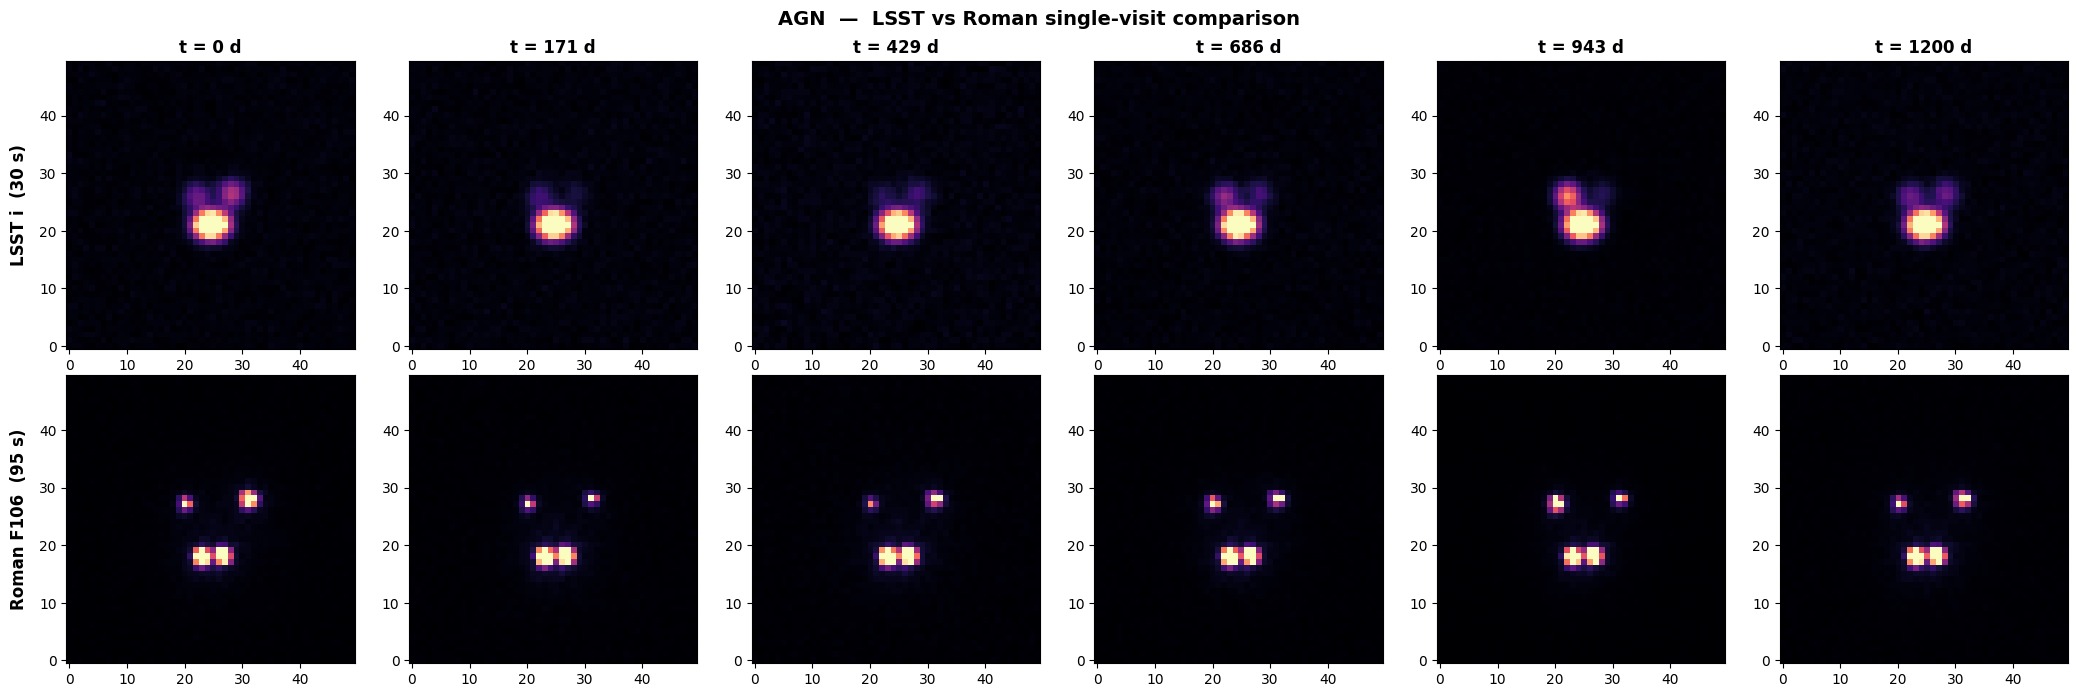

In [10]:
## 9. Side-by-side LSST vs Roman comparison at selected epochs

compare_indices = np.linspace(
    0, len(t_obs_visits) - 1, min(6, len(t_obs_visits)), dtype=int
)

fig, axes = plt.subplots(
    2, len(compare_indices), figsize=(3.5 * len(compare_indices), 7)
)

for col, idx in enumerate(compare_indices):
    t = t_obs_visits[idx]

    li = lsst_visit_images[idx]
    ri = roman_visit_images[idx]

    axes[0, col].imshow(
        li,
        origin="lower",
        cmap="magma",
        vmin=np.percentile(li, 1),
        vmax=np.percentile(li, 99.5),
    )
    axes[0, col].set_title(f"t = {t:.0f} d", fontsize=12, fontweight="bold")

    axes[1, col].imshow(
        ri,
        origin="lower",
        cmap="magma",
        vmin=np.percentile(ri, 1),
        vmax=np.percentile(ri, 99.5),
    )

axes[0, 0].set_ylabel(
    f"LSST {VIS_BAND}  (30 s)", fontsize=12, fontweight="bold", labelpad=8
)
axes[1, 0].set_ylabel(
    f"Roman {ROMAN_VIS_BAND}  ({ROMAN_EXPOSURE_TIME} s)",
    fontsize=12,
    fontweight="bold",
    labelpad=8,
)

fig.suptitle(
    f"{SOURCE_TYPE}  —  LSST vs Roman single-visit comparison",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()

In [ ]:
# ---------------------------------------------------------------------------
# Optional: reset the microlensing track and rerun sections 4–9 to produce
# a different realisation of the microlensing signature.
#
# lens_class.reset_microlensing_model_class(0)
# ---------------------------------------------------------------------------